# get bachground density rho_s based on Winters et al. 1995

In [ ]:
# May 12. Expand to whole domain, not just the Sulu Sea

# May 19. get the data fro the Sulu Sea and Celebes Sea seperately

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import xarray as xr
# import MITgcmutils as mitgcm
import xmitgcm 

%matplotlib inline
import os
import pandas as pd

import sys
from tqdm import tqdm
import psutil
import math

# 1. prepare constants and subroutines

In [2]:
# parameters for EOS equation of state
rho0 = 998.5
T0 = 0
alpha = 2e-4
g=9.81


In [3]:
# def compute_background_PE(ds, rho, i_min,i_max,j_min,j_max, rA_name='rA', drC_name='drF',
#                           hFacC_name='hFacC', g=9.81, time_index=None):
def compute_background_PE(rho,    rA, hFacC, vol, mask,  V_ref_k, z_centers,density_decimals=6):
    """
    Compute background potential energy Eb from dataset `ds`.
    Returns Eb (J) and reference profile (rho_ref, z_ref, V_ref).
    """
    # get fields
    rho_t = xr.DataArray(rho, dims = ('Z','YC','XC'))

    # Expand dr and z to 3D shape of rho_t for volume computations
    # find spatial dims of rho_t
    # spatial_dims = rho_t.dims  # expect (k,j,i) or similar
    # k_dim = spatial_dims[0]    # assume vertical is first dim; adapt if necessary
    # Broadcast dr (1D) to rho_t shape

    # Build rA 3D
    print(rA.shape)
    print(rho_t.shape)
    # rA_3d = rA.broadcast_like(rho_t)

    # hFacC_3d = hFacC.broadcast_like(rho_t)

    # parcel volumes and densities (flatten)
    # vol = (rA_3d.values * dr_3d.values * hFacC_3d.values).ravel()   # 1D numpy array
    
    dens = rho_t.values.ravel()

    # remove zero-volume parcels (if any)
    # mask = vol > 0
    # vol = vol[mask]
    dens = dens[mask].astype(float)  

    # prepare sorted parcels by density (lightest -> heaviest)
    order = np.argsort(dens)   # ascending
    order_rev = order[::-1]  # descending
    dens_sorted = dens[order]
    vol_sorted = vol[order]

    # fill reference layers from bottom to top:
    # Winters stacks heaviest bottom; since dens_sorted is ascending (light->heavy),
    # fill from the end for bottom layers. Simpler: reverse to heavy-first.
    dens_h = dens_sorted[::-1]
    vol_h = vol_sorted[::-1]   # now heavy -> light

    cumv_mid = np.cumsum(vol_h) - 0.5*vol_h

    K = len(V_ref_k)
    rho_ref = np.zeros(K)
    print(rho_ref.dtype)
    # z_ref = z_centers  # numpy array of centers
    # Vref_used = V_ref_k.copy()

    idx = 0         # index in dens_h parcels
    vol_left = vol_h[idx] if len(vol_h)>0 else 0.0

    # iterative fill each reference layer from bottom (k=0 bottom? depends on z ordering)
    # Here we assume dr array was from top to bottom; z_centers from top->down.
    # We want k indices bottom->top, so reverse arrays:
    Vref_bottomup = V_ref_k[::-1]
    z_bottomup = z_centers[::-1]

    # V_edges = np.concatenate(([0], np.cumsum(Vref_bottomup)))

    # np.interp operates on float64 on many builds; cast explicitly to avoid float128 casting errors.
    interp_x = np.asarray(cumv_mid, dtype=np.float64)
    # interp_xp = np.asarray(V_edges[:-1] + 0.5 * Vref_bottomup, dtype=np.float64)
    # interp_fp = np.asarray(z_bottomup, dtype=np.float64)
    # zstar_sorted = np.interp(interp_x, interp_xp, interp_fp)

    # dens_key = np.round(dens_h, decimals=density_decimals)
    # zstar_s = np.empty_like(zstar_sorted) # zstar_s : pdf based 
    # for key in np.unique(dens_key):
    #     m = dens_key == key
    #     # volume-weighted mean reference position for this density class
    #     zstar_group = np.sum(zstar_sorted[m] * vol_h[m]) / np.sum(vol_h[m])
    #     zstar_s[m] = zstar_group

    # zstar = np.empty_like(zstar_s)
    # zstar[order_rev] = zstar_s

    sumV_domain = 0
    sumV_for_interp_list = []
    z_for_interp_list = []
    for kk in range(K):
        # print(kk,sumV_domain)
        V_target = Vref_bottomup[kk]
        sum_rhoV = 0.0
        sumV_filled = 0.0
        if V_target>0:
            sumV_for_interp_list.append(sumV_domain)
            z_for_interp_list.append(z_bottomup[kk])  # start from bottom
        # fill this layer
        # while sumV_filled < V_target:
        while V_target - sumV_filled > 1:
            if idx >= len(dens_h):
                print(idx)
                print(len(dens_h))
                print(V_target, sumV_filled)
                print("take dtype:", take.dtype)
                print("sum_V_filled dtype:", sumV_filled.dtype)
                print("V_target dtype:", V_target.dtype)
                raise RuntimeError(f"Ran out of parcels while filling reference layers.{idx}")
            take = min(vol_left, V_target - sumV_filled)
            sum_rhoV += dens_h[idx] * take

            sumV_for_interp = sumV_filled + 0.5*take  # for interpolation 
            sumV_filled += take
            sumV_domain += take
            vol_left -= take
            if vol_left <= 1e-16:
                # move to next parcel
                idx += 1
                if idx < len(vol_h):
                    vol_left = vol_h[idx]
        if sumV_filled > 1e-16:
            sumV_for_interp_list.append(sumV_domain - 0.5*take)  # for interpolation, use midpoint of the last parcel added
            z_for_interp_list.append(z_bottomup[kk])  # end of this layer
        # print(sumV_for_interp, sumV_filled)
        rho_ref[K-1-kk] = sum_rhoV / V_target  # assign back in top->bottom order
        print(kk, sumV_filled, V_target, idx, rho_ref[K-1-kk])
    
    sumV_for_interp_list = np.array(sumV_for_interp_list)
    z_for_interp_list = np.array(z_for_interp_list)
    interp_xp = np.asarray(sumV_for_interp_list, dtype=np.float64)
    interp_fp = np.asarray(z_for_interp_list, dtype=np.float64)
    zstar_sorted_2 = np.interp(interp_x, interp_xp, interp_fp)
    zstar_2 = np.empty_like(zstar_sorted_2)
    zstar_2[order_rev] = zstar_sorted_2

    # compute Eb:
    # Use z_centers and V_ref_k with same ordering as rho_ref
    # Decide z sign: Winters uses z positive upward. If z_centers from top=0 increasing downward, convert to actual heights.
    # Here we assume z_centers is depth increasing downward; convert to height measured from bottom or top as needed.
    # We'll assume z_centers are heights above bottom. Adjust if needed.
    Eb = g * np.sum(rho_ref * z_centers * V_ref_k)

    # return results
    return Eb, dict(rho_ref=rho_ref, z_ref=z_centers, V_ref=V_ref_k, zstar=zstar_2, sumV_for_interp=sumV_for_interp_list, z_for_interp=z_for_interp_list)


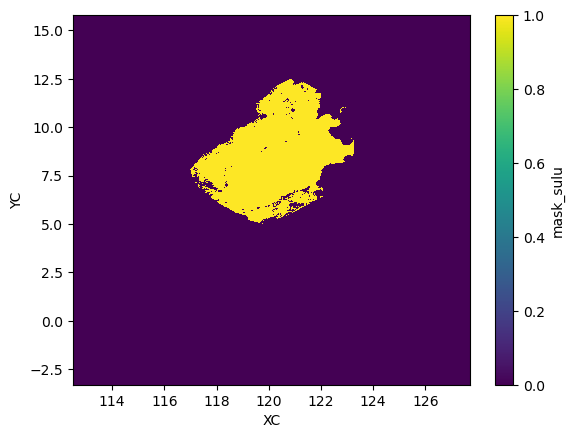

In [4]:
# load mask of Sulu Sea
ds_mask_3basins = xr.open_dataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/masks_3basins.nc')
ds_mask_3basins.mask_sulu.plot()

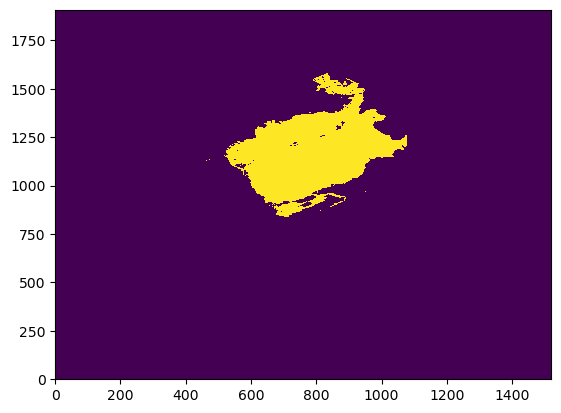

In [5]:
ds_sn = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/',prefix=['outs_sn'],iters=[0])
mask_deep = np.zeros_like(ds_sn.maskC.values[0,:,:])
lon = ds_sn.XC.values
lat = ds_sn.YC.values
mask_sea = ds_sn.maskC.values[0, :,:,]
depth_sea = ds_sn.Depth.values

mask_deep[(mask_sea==1) & (depth_sea>200) & (ds_mask_3basins.mask_sulu.values==1)] = 1

mask_deep_3d = np.broadcast_to(mask_deep, ds_sn.maskC.values.shape)

plt.pcolormesh(mask_deep_3d[60,:,:])

# 2 load data

## 2.1 get APE density profile 

### 2.1.1 get data of one time snapshot

In [9]:
# Get temperature field at time=0 and extract data within the specified range
# Define the index range
# i_min = 836
# i_max = 1579
i_min = 1150
i_max = 1170
j_min = 458+50
j_max = 1077
# j_min = 600
# j_max = 650

ds_sn_test = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/',
                                     prefix=['outs_sn'], iters=[0, 500*180])

# Get temperature at time=0
theta_t0 = ds_sn.THETA.isel(time=0)

# Extract temperature data within the specified range
# Note: xarray uses isel for integer indexing, and we need to include the end index
# theta_subset = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))

# Also get as numpy array if needed
theta_array = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values
mask_deep_3d_subset = mask_deep_3d[:, i_min:i_max+1, j_min:j_max+1]

print(f"Temperature field shape: {theta_t0.shape}")
print(f"Subset shape: {theta_array.shape}")

theta_array[mask_deep_3d_subset == 0] = np.nan
theta_array[theta_array==0] = np.nan
rho0 = 998.5
T0 = 0
alpha = 2e-4
rho_deep = rho0*(1-alpha*(theta_array-T0))
# g=9.81

Temperature field shape: (87, 1908, 1520)
Subset shape: (87, 21, 570)


In [9]:
# icase='033'
ds = ds_sn

nt =571

rho_t = xr.DataArray(rho_deep, dims = ('Z','YC','XC'))
rA = ds['rA'].isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))*mask_deep[i_min:i_max+1, j_min:j_max+1]
drC = ds['drF']    # 1D vertical cell thickness (k,)
hFacC = ds.hFacC
# ensure drC is cell-centered 1D array
dr = drC
# compute cell center z coordinates (assuming drC gives thickness and we have faces)
# simple cumulative: top of domain z_top = 0, compute centers downward
# If ds contains zC or zMid use that instead
# face heights: from z=0 at top, cumulative sum of drC downward; or directly from ds if available
z_faces = ds.Zp1.values
# center heights: midpoints between faces; note sign convention: positive upward?
z_centers = ds.Z.values

# Expand dr and z to 3D shape of rho_t for volume computations
# rA has dims (j,i); expand to (k,j,i)
# hFacC maybe (k,j,i)
# create 3d dr array broadcastable to rho
# find spatial dims of rho_t
spatial_dims = rho_t.dims  # expect (k,j,i) or similar
k_dim = spatial_dims[0]    # assume vertical is first dim; adapt if necessary
# Broadcast dr (1D) to rho_t shape
dr_3d = xr.DataArray(dr.values, dims=(k_dim,), coords={k_dim: ds['drF'].coords['drF']})
dr_3d = dr_3d.broadcast_like(rho_t)

# Build rA 3D
rA_3d = rA.broadcast_like(rho_t)
hFacC_subset = hFacC.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
hFacC_3d = hFacC_subset.broadcast_like(rho_t)

# parcel volumes and densities (flatten)
vol = (rA_3d.astype(np.longdouble).values * dr_3d.astype(np.longdouble).values * hFacC_subset.astype(np.longdouble).values).ravel()   # 1D numpy array
print(vol.shape)
# dens = rho_t.values.ravel()
mask = vol > 0
vol = vol[mask]
# dens = dens[mask]
print(vol.shape)

# total horizontal area A_tot (sum rA over i,j)
# A_tot = rA.sum().compute().item()

# target reference layer volumes: V_ref_k = A_tot * dr_k (dr_k are ds[drC_name])
# V_ref_k = A_tot * dr.values   # numpy 1D length K
V_ref_k = np.zeros(dr.shape[0], dtype=np.longdouble)
# for k in tqdm(range(dr.shape[0])):
for k in range(dr.shape[0]):
    V_ref_k[k] = np.sum((rA_3d.astype(np.longdouble).values * dr_3d.astype(np.longdouble).values * hFacC_subset.astype(np.longdouble).values)[k,:,:])
    print(k,V_ref_k[k])
    
np.save('V_ref_k_sulu_test.npy', V_ref_k)
# Z = z_centers
# # rho_ref_t=[]
# # theta_t2 = []
# for it in tqdm(range(0,nt)):
# # for it in tqdm(range(0,10)):
#     # print(it)

#     theta_t0 = ds_sn.THETA.isel(time=it)
#     theta_subset = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
#     theta_subset_array = theta_subset.values

#     rho_sulu_t = rho0*(1-alpha*(theta_subset_array-T0))
#     Eb, ref = compute_background_PE(rho_sulu_t, rA, hFacC, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state
#     # rho_ref_t.append(ref['rho_ref'])
#     theta_ref = 1/alpha*(1-ref['rho_ref']/rho0)+T0
    
#     # Z = z_centers
#     # t = np.arange(0,rho_ref_t2.shape[0], 1)
    
#     theta_ref_ds = xr.Dataset(
#         {
#             "theta_ref": (("Z"), theta_ref)
#         },
#         coords={
#             "Z": Z
#         }
#     )
#     # theta_ref_ds.to_netcdf('theta_ref/theta_ref_exp7_ctrl.nc')
#     theta_ref_ds.to_netcdf(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc','w')
#     get_ram_info()
#     # theta_t2.append(theta_subset_array)

(1041390,)
(435850,)
0 328642049187.5
1 328642049187.5
2 328642049187.5
3 328642049187.5
4 328642049187.5
5 328642049187.5
6 328642049187.5
7 328642049187.5
8 328153806616.67702425
9 326744681815.84073207
10 324609681771.06854957
11 321770637615.07143074
12 317735822388.31574085
13 314536030134.28473943
14 312543316548.75125915
15 326909062535.16608965
16 360331432243.62400737
17 417980197169.10441548
18 505821667110.61004308
19 631637502021.78810084
20 788463639315.13661134
21 980291523577.131199
22 1213106830119.8925734
23 1495009686937.5013616
24 1836501842567.2509474
25 2100797477292.8477039
26 2217671773433.9367793
27 2160873598725.3489637
28 2023014602399.3218813
29 1659949608193.5620139
30 1360561664144.8341146
31 1174376134755.7716804
32 1010974683969.7154516
33 873502553349.22616607
34 752638514197.90458053
35 651196445403.8651813
36 577150166082.76747346
37 519118120803.4670766
38 475448196392.2953999
39 444301811069.5717389
40 421728492791.37857822
41 397953013707.88500875
4

In [21]:
z_centers = ds.Z.values
Z = z_centers

for it in range(1):
# for it in tqdm(range(0,10)):
    # print(it)

    theta_t0 = ds_sn_test.THETA.isel(time=it)
    # theta_subset = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
    theta_array = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values

    rA_subset = ds_sn_test['rA'].isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
    rho_sulu_t = rho0*(1-alpha*(theta_array-T0))
    Eb, ref = compute_background_PE(rho_sulu_t, rA_subset, hFacC_subset, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state
    # rho_ref_t.append(ref['rho_ref'])
    theta_ref = 1/alpha*(1-ref['rho_ref']/rho0)+T0
    
    # Z = z_centers
    # t = np.arange(0,rho_ref_t2.shape[0], 1)
    
    theta_ref_ds = xr.Dataset(
        {
            "theta_ref": (("Z"), theta_ref)
        },
        coords={
            "Z": Z
        }
    )
    # theta_ref_ds.to_netcdf('theta_ref/theta_ref_exp7_ctrl.nc')
    # theta_ref_ds.to_netcdf(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc','w')
    # get_ram_info()
    # theta_t2.append(theta_subset_array)

(21, 570)
(87, 21, 570)
float64
0 39755059.967396548018 39755059.967396548018 13 997.5753784179688
1 1131749453.6583757028 1131749453.6583757028 72 997.5747680664062
2 3040973081.0391420964 3040973081.0391420964 199 997.5738525390625
3 4560157869.3723346107 4560157869.3723346107 367 997.5728759765625
4 5746263998.265309492 5746263998.265309492 578 997.5718383789062
5 6970496915.28090802 6970496915.28090802 821 997.5711669921875
6 7984951195.3839402646 7984951195.3839402646 1100 997.5706176757812
7 9009814802.858349495 9009814802.858349495 1408 997.5700073242188
8 10003954043.938296149 10003954043.938296149 1590 997.5696411132812
9 10846543154.998345138 10846543154.998345138 1787 997.5696411132812
10 11542797339.593547024 11542797339.593547024 1997 997.5696411132812
11 12236543955.824570078 12236543955.824570078 2224 997.5696411132812
12 13028096303.751311172 13028096303.751311172 2462 997.5696411132812
13 14503709640.093093202 14503709640.093093202 2728 997.5696411132812
14 16370537783

In [ ]:
z_centers = ds.Z.values
Z = z_centers

for it in range(1):
# for it in tqdm(range(0,10)):
    # print(it)

    theta_t0 = ds_sn_test.THETA.isel(time=it)
    # theta_subset = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
    theta_array = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values

    rA_subset = ds_sn_test['rA'].isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
    rho_sulu_t = rho0*(1-alpha*(theta_array-T0))
    Eb, ref = compute_background_PE(rho_sulu_t, rA_subset, hFacC_subset, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state
    # rho_ref_t.append(ref['rho_ref'])
    theta_ref = 1/alpha*(1-ref['rho_ref']/rho0)+T0
    
    # Z = z_centers
    # t = np.arange(0,rho_ref_t2.shape[0], 1)
    
    theta_ref_ds = xr.Dataset(
        {
            "theta_ref": (("Z"), theta_ref)
        },
        coords={
            "Z": Z
        }
    )
    # theta_ref_ds.to_netcdf('theta_ref/theta_ref_exp7_ctrl.nc')
    # theta_ref_ds.to_netcdf(f'theta_ref_linear_case_{icase}/theta_ref_t_{it:03d}.nc','w')
    # get_ram_info()
    # theta_t2.append(theta_subset_array)

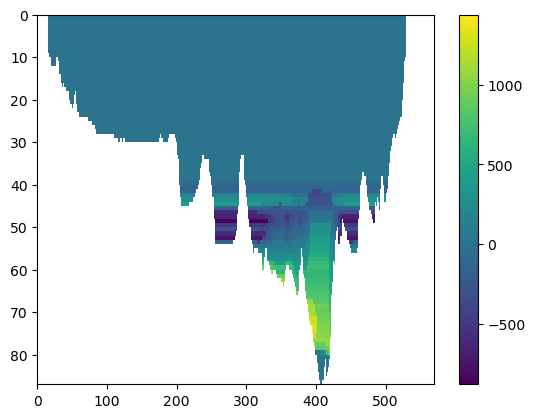

In [331]:
plt.pcolormesh(zstar_all[:,20,:] - z_centers[:, None])
plt.colorbar()
plt.gca().invert_yaxis()

In [329]:
z_centers

array([  -12.5    ,   -37.5    ,   -62.5    ,   -87.5    ,  -112.5    ,
        -137.5    ,  -162.5    ,  -187.5    ,  -212.5    ,  -237.5    ,
        -262.5    ,  -287.5    ,  -312.5    ,  -337.5    ,  -362.5    ,
        -388.1473 ,  -415.90417,  -447.61142,  -485.58655,  -532.7471 ,
        -592.11865,  -666.8631 ,  -760.9607 ,  -879.4226 , -1028.5573 ,
       -1209.8336 , -1415.7917 , -1635.2606 , -1856.1685 , -2065.0842 ,
       -2253.1382 , -2419.8608 , -2567.6719 , -2698.7163 , -2814.8962 ,
       -2917.8977 , -3010.0662 , -3094.0708 , -3171.9966 , -3245.651  ,
       -3316.5981 , -3385.3362 , -3451.681  , -3515.7156 , -3577.5208 ,
       -3637.1738 , -3694.75   , -3750.3213 , -3803.9578 , -3855.7266 ,
       -3905.693  , -3953.9197 , -4000.4673 , -4045.394  , -4088.7563 ,
       -4130.609  , -4171.0044 , -4209.9937 , -4247.625  , -4283.946  ,
       -4319.0024 , -4352.8384 , -4385.496  , -4417.0166 , -4447.44   ,
       -4476.8037 , -4505.145  , -4532.4995 , -4558.989  , -4584

In [22]:
zstar_all = np.full(rho_t.shape, np.nan, dtype=float)
zstar_all.ravel()[mask] = ref["zstar"]
zstar_all[:, 20, 260]-z_centers

array([   0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        , -144.6015625 , -206.0300293 ,
       -260.92260742, -309.41381836,  -64.03466797,  130.37939453,
        331.86987305, -166.78393555, -210.94311523, -338.43505859,
       -643.48217773, -315.27783203,  -48.2265625 , -256.07397461,
       -609.71386719,    0.        ,           nan,           nan,
                 nan,           nan,           nan,           

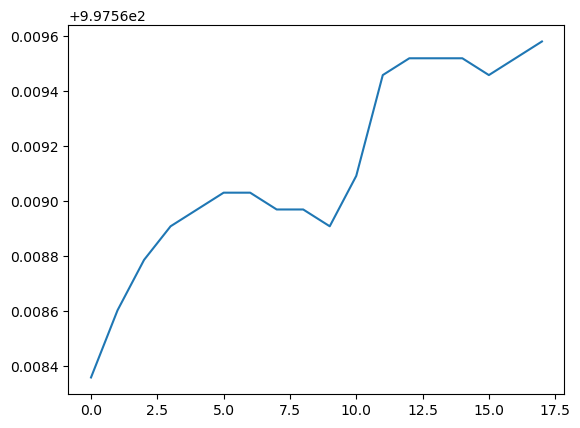

In [323]:
plt.plot(rho0*(1-alpha*(theta_array[35:53,20,260])))

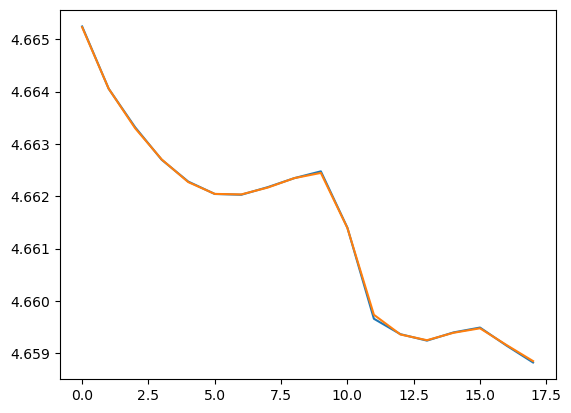

In [340]:
plt.plot(ds_sn_test.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).THETA.isel(YC=20, XC=260,Z=slice(35,53)).values.T)

(87, 21, 570)
(435850,)
(435850,)


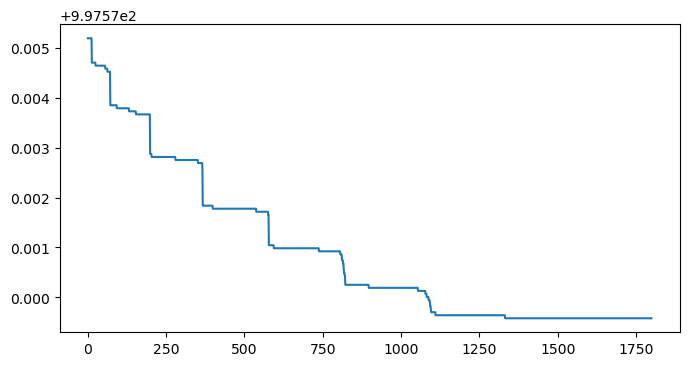

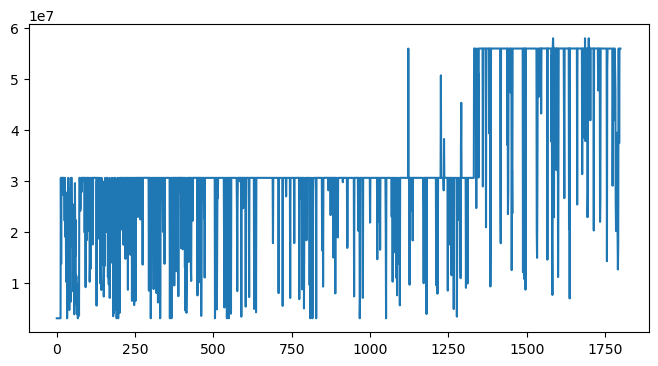

In [332]:
# rho , vol, mask 

rho_t = xr.DataArray(rho_sulu_t, dims = ('Z','YC','XC'))
spatial_dims = rho_t.dims  # expect (k,j,i) or similar

print(rho_t.shape)

dens = rho_t.values.ravel()
dens = dens[mask]
print(dens.shape)
print(vol.shape)
# prepare sorted parcels by density (lightest -> heaviest)
order = np.argsort(dens)   # ascending
order_rev = order[::-1]  # descending
dens_sorted = dens[order]
vol_sorted = vol[order]

dens_h = dens_sorted[::-1]
vol_h = vol_sorted[::-1]   # now heavy -> light

plt.figure(figsize=(8,4))
plt.plot(np.arange(0, 1800), dens_h[0:1800], label='dens_h')
plt.figure(figsize=(8,4))   
plt.plot(np.arange(0, 1800), vol_h[0:1800], label='vol_h')

In [ ]:
vol_3d = (rA_3d.astype(np.longdouble).values * dr_3d.astype(np.longdouble).values * hFacC_subset.astype(np.longdouble).values)

In [165]:
# find the number of parcels in each reference layer that are non-zero volume and get the total volume of those parcels
non_zero_parcels = np.sum(vol_3d > 0, axis=(1, 2))
total_volume_non_zero_parcels = np.sum(vol_3d * (vol_3d > 0), axis=(1, 2))
print(non_zero_parcels[::-1])  # print from bottom to top
for k in range(87,0,-1):
    print(k,np.cumsum(non_zero_parcels[::-1])[87-k], total_volume_non_zero_parcels[k-1], rho_sulu_t[k-1,0, 400])

# concatenate all non-zero vol_3d parcels into a single 1D array
non_zero_volumes = vol_3d[vol_3d > 0].ravel() 
non_zero_volumes = non_zero_volumes[::-1]  # reverse to match heavy->light order
non_zero_volumes.shape

# concatenate all the density of  non-zero vol_3d parcels into a single 1D array, in the same order as non_zero_volumes
non_zero_densities = rho_sulu_t[vol_3d > 0].ravel()
non_zero_densities = non_zero_densities[::-1]  # reverse to match heavy->light order

[   13    59   127   168   211   243   279   308   338   367   389   410
   442   500   558   585   612   632   658   678   705   728   755   796
   861   992  1331  1645  1838  2018  2205  2441  2641  2832  3020  3144
  3252  3379  3532  3659  3888  4124  4427  4623  4752  4869  4980  5099
  5204  5333  5443  5561  5708  5863  6015  6210  6356  7370  7699  8126
  8600  8884  9147  9356  9543  9686  9787  9858  9942 10037 10121 10195
 10247 10326 10450 10572 10652 10714 10748 10748 10748 10748 10748 10748
 10748 10748 10748]
87 13 39755059.967396548018 997.5754
86 72 1131749453.6583757028 997.57477
85 199 3040973081.0391420964 997.57385
84 367 4560157869.3723346107 997.5729
83 578 5746263998.265309492 997.57184
82 821 6970496915.28090802 997.57117
81 1100 7984951195.3839402646 997.5706
80 1408 9009814802.858349495 997.57
79 1746 10003954043.938296149 997.56946
78 2113 10846543154.998345138 997.5691
77 2502 11542797339.593547024 997.569
76 2912 12236543955.824570078 997.56885
75 3354 13

In [29]:
zstar_t = np.zeros((87, 40))
rho_t = np.zeros((87, 40))
for it in range(40):
    # print(it)
    zstar_2 = xr.open_dataset(f'rhoref_zstar_linear_case_ctrl/zstar2_t_{it:03d}.nc')
    zstar_t[:, it] = zstar_2['z_star'][:,20,260]
    rho_t[:, it] = zstar_2['rho_ref'].values
    # plt.plot(zstar_2['rho_ref'][:].values)
    # plt.plot(rho_sulu_t[:,20,260])

Text(0, 0.5, 'Depth (m)')

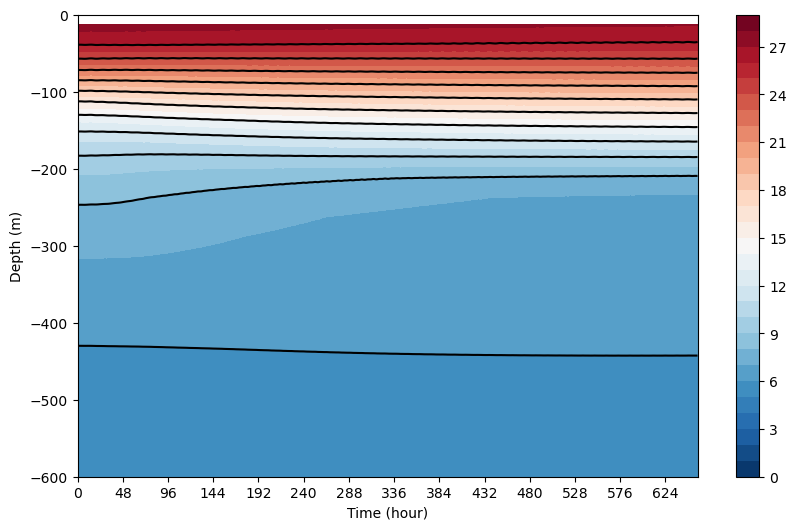

In [124]:
tref_ctrl = xr.open_dataset('theta_ref/theta_ref_exp7_ctrl.nc')
plt.figure(figsize=(10,6))
plt.contourf(np.arange(659),z_centers,tref_ctrl.theta_ref.values.T, levels=np.arange(0,30,1),cmap='RdBu_r')
plt.colorbar()
plt.contour(np.arange(659),z_centers,tref_ctrl.theta_ref.values.T, levels=np.arange(0,30,2),colors='k')
plt.ylim(-600,0)

plt.xticks(np.arange(0,659,48))

plt.xlabel('Time (hour)')
plt.ylabel('Depth (m)')



(-600.0, 0.0)

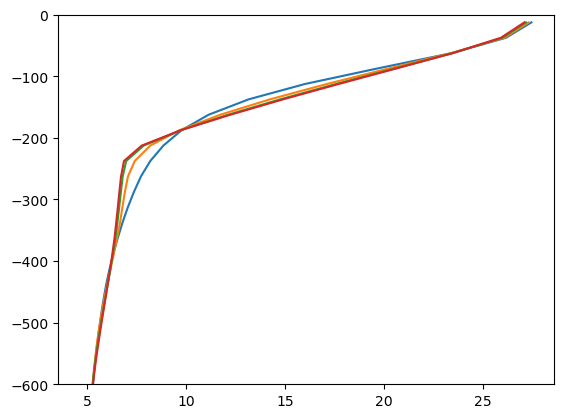

In [84]:
plt.plot(tref_ctrl.theta_ref.values[0,:],z_centers,)
plt.plot(tref_ctrl.theta_ref.values[240,:],z_centers,)
plt.plot(tref_ctrl.theta_ref.values[480,:],z_centers,)
plt.plot(tref_ctrl.theta_ref.values[650,:],z_centers,)
plt.ylim(-600,0)

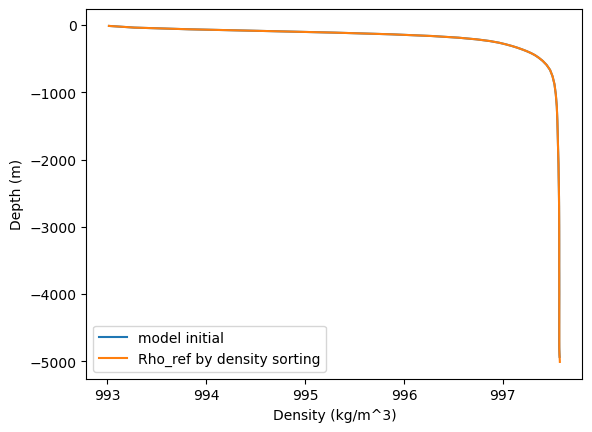

In [189]:
theta_ref_ds = xr.open_dataset('rhoref_zstar_linear_case_ctrl/rhoref_zstar_t_000.nc')
# theta_ref_ds.rho_ref.plot()

rho_ini_model = xr.open_zarr('/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output/rho.zarr', consolidated=False)
rho00 = rho_ini_model.rho.isel(time=0, x=1079, y=749).values
rho00[rho00==np.nanmax(rho00)] = np.nan
plt.plot( rho00, ds_sn_test.Z.values, label='model initial')
plt.plot( theta_ref_ds.rho_ref.values, ds_sn_test.Z.values, label = 'Rho_ref by density sorting')
plt.xlabel('Density (kg/m^3)')
plt.ylabel('Depth (m)')
plt.legend()

In [205]:
theta_ref = []
for it in tqdm(range(500)):
    theta_ref_ds = xr.open_dataset(f'rhoref_zstar_linear_case_ctrl/rhoref_zstar_t_{it:03d}.nc')
    theta_ref.append(theta_ref_ds['rho_ref'].values)


100%|██████████| 500/500 [00:17<00:00, 28.99it/s]


(-600.0, 0.0)

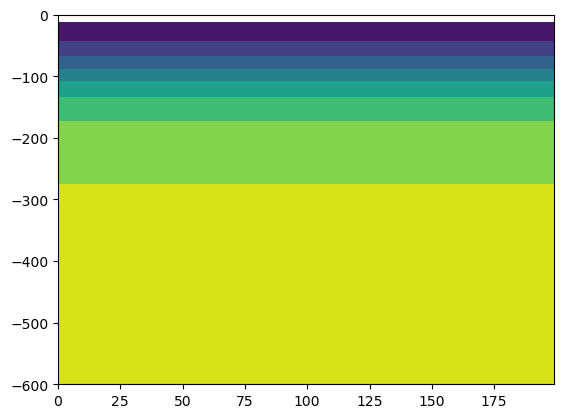

In [204]:
theta_ref_array = np.array(theta_ref)  # shape (time, Z)
plt.contourf(np.arange(200), ds_sn_test.Z.values, theta_ref_array.T)
plt.ylim(-600,0)

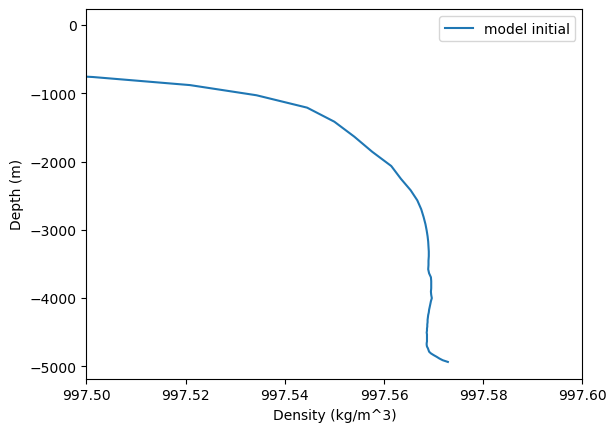

In [191]:
plt.plot( rho00, ds_sn_test.Z.values, label='model initial')
plt.xlim(997.5,997.6)
plt.xlabel('Density (kg/m^3)')
plt.ylabel('Depth (m)')
plt.legend()

### 2.1.2 validate the zarr Theta and rho



In [40]:
zarr_file = '/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output'

theta = xr.open_zarr(os.path.join(zarr_file, 'theta.zarr'), consolidated=False)
rho = xr.open_zarr(os.path.join(zarr_file, 'rho.zarr'), consolidated=False)

In [34]:
ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/', prefix=['outs_sn'], iters=[80*180])

In [29]:
# find the location closest to 120E and 8N by lon and lat 
lon, lat = np.meshgrid(ds.XC.values, ds.YC.values)
# lat = ds.YC.values
lon_target = 121
lat_target = 3
lon_diff = np.abs(lon - lon_target)
lat_diff = np.abs(lat - lat_target)
total_diff = lon_diff + lat_diff
j_closest_cele, i_closest_cele = np.unravel_index(np.argmin(total_diff), lon.shape)
print(f'Closest grid point to ({lon_target}E, {lat_target}N) is at index ({j_closest_cele}, {i_closest_cele})/ total index ({lon.shape[0]}, {lon.shape[1]}) with coordinates ({lon[j_closest_cele, i_closest_cele]}E, {lat[j_closest_cele, i_closest_cele]}N)')
# print(depth_sea[j_closest_cele, i_closest_cele])

Closest grid point to (121E, 3N) is at index (629, 849)/ total index (1908, 1520) with coordinates (120.99500274658203E, 2.994999885559082N)


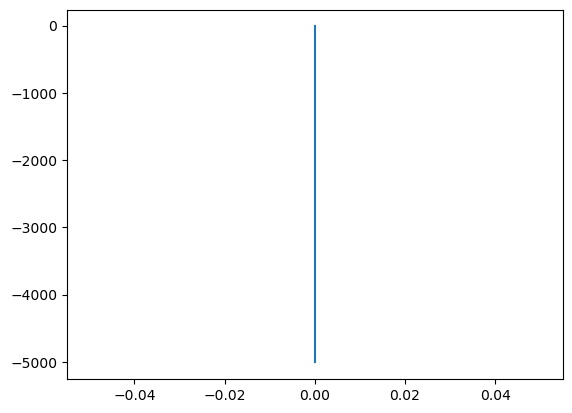

In [37]:
# i_tst = 1579
# j_tst = 1077

# plt.plot(theta.theta.isel(time=80, y=j_closest_cele, x=i_closest_cele), ds['Z'].values)
plt.plot(ds['THETA'].isel(time=0, YC=j_closest_cele, XC=i_closest_cele)-theta.theta.isel(time=80, y=j_closest_cele, x=i_closest_cele).values, ds['Z'].values)

In [38]:
tp = theta.theta.isel(time=0, y=j_closest_cele, x=i_closest_cele)

rhop = rho0*(1-alpha*(tp-T0))

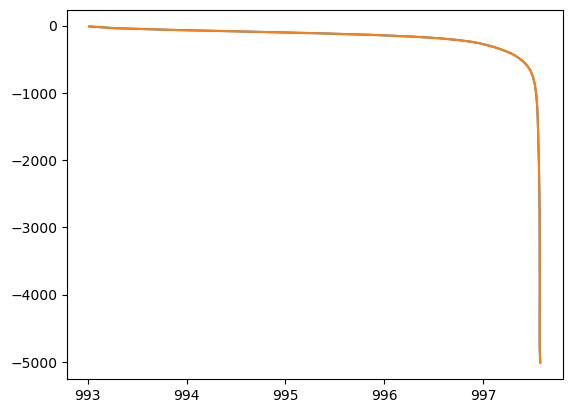

In [39]:
plt.plot(rhop, ds['Z'].values)
plt.plot(rho.rho.isel(time=0, y=j_closest_cele, x=i_closest_cele), ds['Z'].values)


## 2.2 get mean APE in the Sulu Sea and Celebes Sea seperately

In [7]:
i_min = 836
i_max = 1579
j_min = 508
j_max = 1077

In [ ]:
zarr_file = '/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output'

rho = xr.open_zarr(os.path.join(zarr_file, 'rho.zarr'), consolidated=False)
rho_mean = rho.mean(dim=['time'])

rho_mean_sulu = rho_mean.isel(y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))
# save rho_mean to zarr
rho_mean_sulu.to_netcdf(os.path.join(zarr_file, 'rho_mean_sulu.nc'), mode='w')


In [30]:

# i_min = 836
# i_max = 1579
# j_min = 508
# j_max = 1077
vreffile = '/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/V_ref_k_sulu.npy'

CASE_DIR = f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/'

ds_mask_3basins = xr.open_dataset('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/masks_3basins.nc')

print("Loading grid and mask fields...")
ds_mask = xmitgcm.open_mdsdataset(CASE_DIR, prefix=["outs_sn"],iters=[0])
mask_deep = np.zeros_like(ds_mask.maskC.values[0,:,:])
lon = ds_mask.XC.values
lat = ds_mask.YC.values
mask_sea = ds_mask.maskC.values[0, :,:,]
depth_sea = ds_mask.Depth.values
mask_deep[(mask_sea==1) & (depth_sea>200) & (ds_mask_3basins.mask_sulu.values==1)] = 1
mask_deep_3d = np.broadcast_to(mask_deep, ds_mask.maskC.values.shape)

print(f"Processing mean rho fields...")

# theta_t0 = ds_mask.THETA.isel(time=0)
# theta_array = theta_t0.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values
mask_deep_3d_subset = mask_deep_3d[:, i_min:i_max+1, j_min:j_max+1]
# theta_array[mask_deep_3d_subset == 0] = np.nan
# theta_array[theta_array==0] = np.nan

# rho_sulu = rho0 * (1 - alpha * (theta_array - T0))

rho_t = xr.DataArray(rho_mean_sulu.rho.values, dims=("Z", "YC", "XC"))
rA = ds_mask["rA"].isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)) * mask_deep[i_min:i_max+1, j_min:j_max+1]
dr = ds_mask["drF"] # center
hFacC = ds_mask.hFacC.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1))
z_centers = ds_mask.Z.values

spatial_dims = rho_t.dims
k_dim = spatial_dims[0]
dr_3d = xr.DataArray(dr.values, dims=(k_dim,), coords={k_dim: ds_mask["drF"].coords["drF"]})
dr_3d = dr_3d.broadcast_like(rho_t)
rA_3d = rA.broadcast_like(rho_t)

vol = (
    rA_3d.astype(np.longdouble).values
    * dr_3d.astype(np.longdouble).values
    * hFacC.astype(np.longdouble).values
).ravel()
mask = vol > 0
vol = vol[mask]

V_ref_k = np.load(vreffile)

rho_t = rho_mean_sulu
_, ref = compute_background_PE(rho_t, rA, hFacC, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state

zstar_all = np.full(rho_t.shape, np.nan, dtype=float)
zstar_all.ravel()[mask] = ref["zstar"]

theta_ref_ds = xr.Dataset(
    data_vars={
        "z_star": (("Z", "y", "x"), zstar_all),
        "rho_ref": (("Z",), ref["rho_ref"]),
    },
    coords={"Z": z_centers,
            "x": theta_t0.XC.isel(XC=slice(j_min, j_max+1)).values, 
            "y": theta_t0.YC.isel(YC=slice(i_min, i_max+1)).values},
)

# theta_ref_ds.to_netcdf(case_folder / f"rhoref_zstar_t_{it:03d}.nc", mode="w")

# del ds_sn

Loading grid and mask fields...
Processing mean rho fields...


AttributeError: 'numpy.ndarray' object has no attribute 'rho'

In [ ]:

zarr_dir = "/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output/"
theta_ref_ds.to_netcdf(zarr_dir + "rhoref_zstar_mean.nc", mode="w")


## 3. get flucuating part of APE based on EQ.15 Zemskova (2015)

In [8]:
# ape_f = rho(x,t)*zstar(rho(x,t)) - rho_mean*zstar(rho_mean)
## load data
nz = 87
zarr_dir = '/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output/'

rho = xr.open_zarr(os.path.join(zarr_dir, 'rho.zarr'), consolidated=False)
rho_sulu = rho.isel(y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))
ds_mean_sulu = xr.open_dataset(zarr_dir + "rho_mean_sulu.nc")
rho_mean_sulu = ds_mean_sulu.rho.values

zstar_t = np.zeros((40, nz,  i_max-i_min+1, j_max-j_min+1))
for it in tqdm(range(240,280)):
    ds_rhoref = xr.open_dataset(f'rhoref_zstar_linear_case_ctrl/rhoref_zstar_t_{it:03d}.nc')

    zstar_t[it-240, :, :, :] = ds_rhoref.z_star.values

zstar_mean = xr.open_dataset(zarr_dir + "rhoref_zstar_mean.nc").z_star


100%|██████████| 40/40 [00:19<00:00,  2.02it/s]


In [9]:
ape_f = np.zeros((40, nz,  i_max-i_min+1, j_max-j_min+1))
ape_f0_1 = np.zeros((40, nz,  i_max-i_min+1, j_max-j_min+1))
ape_f0_2 = np.zeros((40, nz,  i_max-i_min+1, j_max-j_min+1))

for it in tqdm(range(240,280)):
    ape_f[it-240, :, :, :] = rho_sulu.rho.isel(time=it).values*zstar_t[it-240,:,:,:] - rho_mean_sulu*zstar_mean.values
    ape_f0_1[it-240, :, :, :] = rho_sulu.rho.isel(time=it).values*zstar_t[it-240,:,:,:]
    ape_f0_2[it-240, :, :, :] = rho_mean_sulu*zstar_mean.values
    # ape_f_ds = xr.Dataset(
    #     {
    #         "ape_f": (("Z", "y", "x"), ape_f.values)
    #     },
    #     coords={
    #         "Z": z_centers,
    #         "y": theta_t0.YC.isel(YC=slice(i_min, i_max+1)).values,
    #         "x": theta_t0.XC.isel(XC=slice(j_min, j_max+1)).values
    #     }
    # )
    # ape_f_ds.to_netcdf(f'ape_f/ape_f_t_{it:03d}.nc', mode='w')

100%|██████████| 40/40 [03:19<00:00,  5.00s/it]


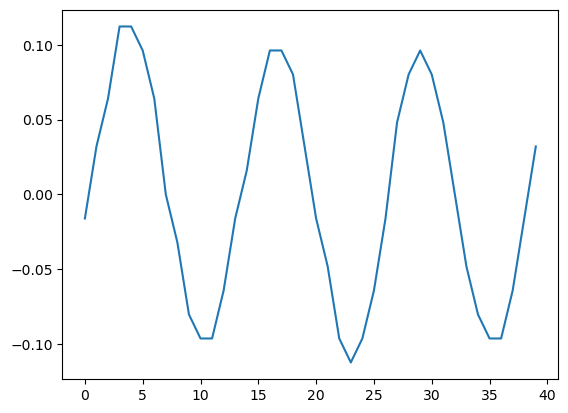

In [13]:
plt.plot(ape_f0_1[:,10,300,300] - ape_f0_2[:,10,300,300])

In [18]:
rho_mean_sulu[10,300,300]

996.96204

In [23]:
rho_sulu_array =rho_sulu.rho.isel(time=slice(240,280)).values

In [30]:
rho_sulu_array[:,10, 300,300] - rho_mean_sulu[10,300,300]

array([ 6.1035156e-05, -1.2207031e-04, -2.4414062e-04, -4.2724609e-04,
       -4.2724609e-04, -3.6621094e-04, -2.4414062e-04,  0.0000000e+00,
        1.2207031e-04,  3.0517578e-04,  3.6621094e-04,  3.6621094e-04,
        2.4414062e-04,  6.1035156e-05, -6.1035156e-05, -2.4414062e-04,
       -3.6621094e-04, -3.6621094e-04, -3.0517578e-04, -1.2207031e-04,
        6.1035156e-05,  1.8310547e-04,  3.6621094e-04,  4.2724609e-04,
        3.6621094e-04,  2.4414062e-04,  6.1035156e-05, -1.8310547e-04,
       -3.0517578e-04, -3.6621094e-04, -3.0517578e-04, -1.8310547e-04,
        0.0000000e+00,  1.8310547e-04,  3.0517578e-04,  3.6621094e-04,
        3.6621094e-04,  2.4414062e-04,  6.1035156e-05, -1.2207031e-04],
      dtype=float32)

In [84]:
## check ape_f from zarr
ape_f_zarr = xr.open_zarr(os.path.join(zarr_dir, 'ape_f.zarr'), consolidated=False)
ape_f_bp = xr.open_zarr(os.path.join(zarr_dir, 'ape_f_bp_semidiurnal.zarr'), consolidated=False)
ke_bp = xr.open_zarr('zarr_output/ke_bc_bp_semidiurnal.zarr', consolidated=False)


In [28]:
ape_f0_1[:,10, 300,300] - ape_f0_2[:,10, 300,300]

array([-0.01602173,  0.03204346,  0.06408691,  0.1121521 ,  0.1121521 ,
        0.09613037,  0.06408691,  0.        , -0.03204346, -0.08010864,
       -0.09613037, -0.09613037, -0.06408691, -0.01602173,  0.01602173,
        0.06408691,  0.09613037,  0.09613037,  0.08010864,  0.03204346,
       -0.01602173, -0.04806519, -0.09613037, -0.1121521 , -0.09613037,
       -0.06408691, -0.01602173,  0.04806519,  0.08010864,  0.09613037,
        0.08010864,  0.04806519,  0.        , -0.04806519, -0.08010864,
       -0.09613037, -0.09613037, -0.06408691, -0.01602173,  0.03204346])

In [29]:
ape_f[:, 10, 300,300]

array([-0.01602173,  0.03204346,  0.06408691,  0.1121521 ,  0.1121521 ,
        0.09613037,  0.06408691,  0.        , -0.03204346, -0.08010864,
       -0.09613037, -0.09613037, -0.06408691, -0.01602173,  0.01602173,
        0.06408691,  0.09613037,  0.09613037,  0.08010864,  0.03204346,
       -0.01602173, -0.04806519, -0.09613037, -0.1121521 , -0.09613037,
       -0.06408691, -0.01602173,  0.04806519,  0.08010864,  0.09613037,
        0.08010864,  0.04806519,  0.        , -0.04806519, -0.08010864,
       -0.09613037, -0.09613037, -0.06408691, -0.01602173,  0.03204346])

In [118]:
# plt.plot(ape_f_zarr.ape_f[:, 50, 300, 300])
# plt.plot(ape_f[:, 10, 300, 300])
# plt.plot(ape_f_bp.ape_f_bp_semidiurnal[:, 10, 300, 300])
# plt.plot(ape_f_bp.ape_f_bp_semidiurnal[420, :, 300, 300])

ds_sn_test = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/',
                                     prefix=['outs_sn'], iters=[0,])

hFacC = ds_sn_test.hFacC
dr = ds_sn_test.drF.values
hFacC_subset = hFacC.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values
ape_f_bp_vavg = np.zeros((50, i_max-i_min+1, j_max-j_min+1))
ke_bp_vavg = np.zeros((50, i_max-i_min+1, j_max-j_min+1))
ape_f_bp_int = np.zeros((50, i_max-i_min+1, j_max-j_min+1))
ke_bp_int = np.zeros((50, i_max-i_min+1, j_max-j_min+1))
for it in tqdm(range(400,450)):
    ape_f_bp_vavg[it-400] = np.sum(ape_f_bp.ape_f_bp_semidiurnal.isel(time=it,z=slice(0,36))*hFacC_subset[0:36]*dr[:36, None, None], axis=0)/np.sum(hFacC_subset[0:36]*dr[:36, None, None], axis=0)
    ke_bp_vavg[it-400] = rho0*np.sum(ke_bp.ke_bc_bp_semidiurnal.isel(time=it, y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))*hFacC_subset*dr[:, None, None], axis=0)/np.sum(hFacC_subset*dr[:, None, None], axis=0)
    ape_f_bp_int[it-400] = np.sum(ape_f_bp.ape_f_bp_semidiurnal.isel(time=it,z=slice(0,36))*hFacC_subset[0:36]*dr[:36, None, None], axis=0)
    ke_bp_int[it-400] = rho0*np.sum(ke_bp.ke_bc_bp_semidiurnal.isel(time=it, y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))*hFacC_subset*dr[:, None, None], axis=0)
    

100%|██████████| 50/50 [08:19<00:00,  9.99s/it]


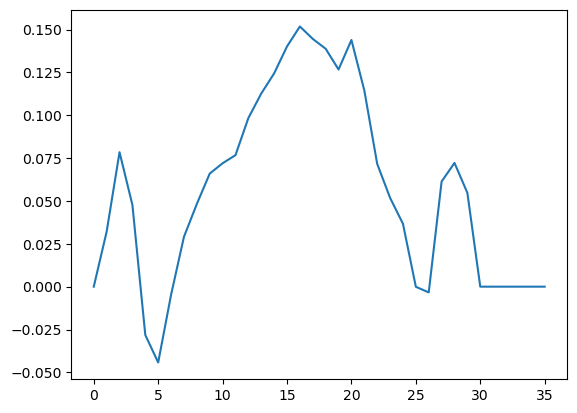

In [74]:
plt.plot(ape_f_bp.ape_f_bp_semidiurnal[420, :36, 300, 300])

Text(0.5, 1.0, 'Vertically Integrated Semidiurnal KE (J/m^2)')

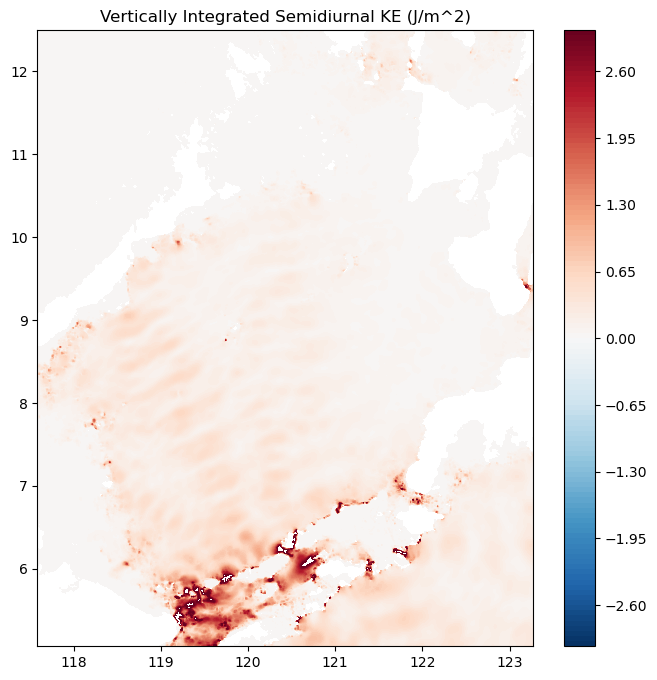

In [144]:
lon_sulu = ds_sn_test.XC.isel(XC=slice(j_min, j_max+1)).values
lat_sulu = ds_sn_test.YC.isel(YC=slice(i_min, i_max+1)).values
ke_bp_int[ke_bp_int==0] = np.nan
plt.figure(figsize=(8,8))
plt.contourf(lon_sulu, lat_sulu, np.mean(ke_bp_int[:, :, :], axis=0), cmap='RdBu_r', levels = np.arange(-3., 3.05, 0.05))
plt.colorbar()
plt.title('Vertically Integrated Semidiurnal KE (J/m^2)')

Text(0.5, 1.0, 'Vertically Integrated Semidiurnal APE+KE (J/m^2)')

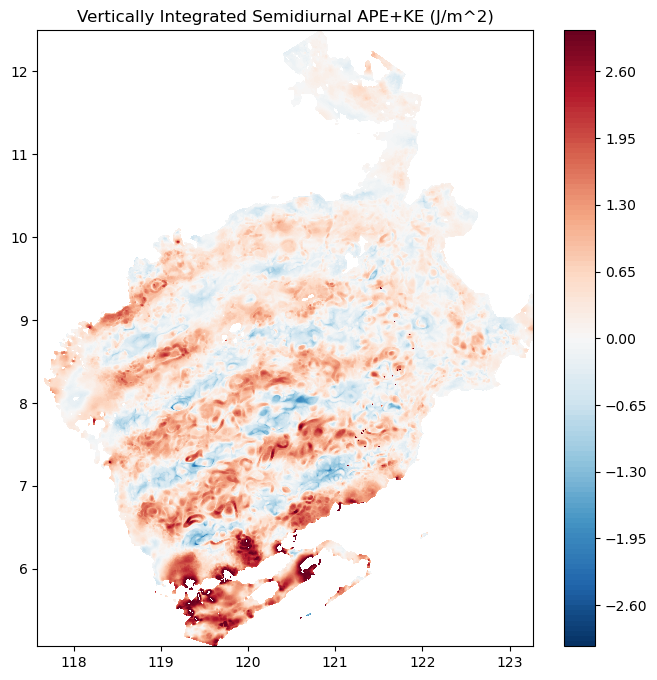

In [145]:
plt.figure(figsize=(8,8))
plt.contourf(lon_sulu, lat_sulu, 
             np.mean(ape_f_bp_int[:, :, :]+ke_bp_int[:, :, :], axis=0), cmap='RdBu_r', levels = np.arange(-3, 3.05, 0.05), vmax=3, vmin=-3)
plt.colorbar()
plt.title('Vertically Integrated Semidiurnal APE+KE (J/m^2)')

Text(0.5, 1.0, 'Vertically Integrated Semidiurnal APE (J/m^2)')

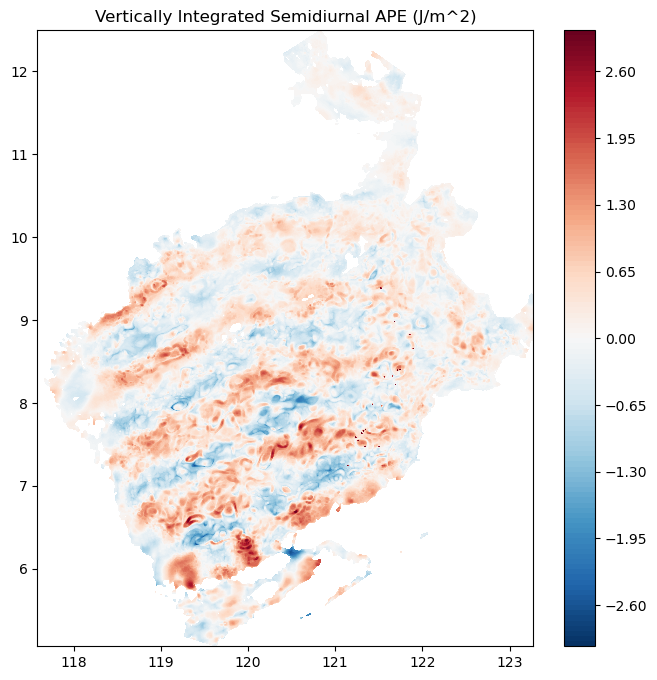

In [146]:
ape_f_bp_int[ape_f_bp_int==0] = np.nan
plt.figure(figsize=(8,8))
plt.contourf(lon_sulu, lat_sulu, np.mean(ape_f_bp_int[:, :, :], axis=0), cmap='RdBu_r', levels = np.arange(-3., 3.05, 0.05))
plt.colorbar()
plt.title('Vertically Integrated Semidiurnal APE (J/m^2)')

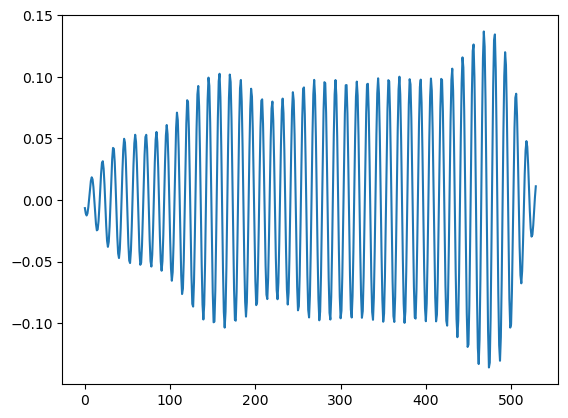

In [116]:
plt.plot(ape_f_bp.ape_f_bp_semidiurnal[:, 10, 300, 300])


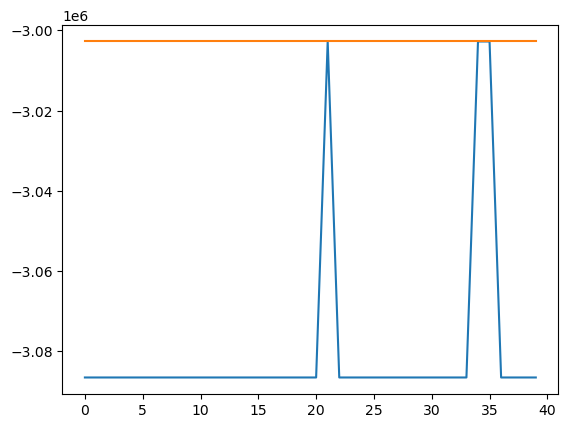

In [62]:
plt.plot(ape_f0_1[:,36,  270, 300])
plt.plot(ape_f0_2[:,36,  270, 300])

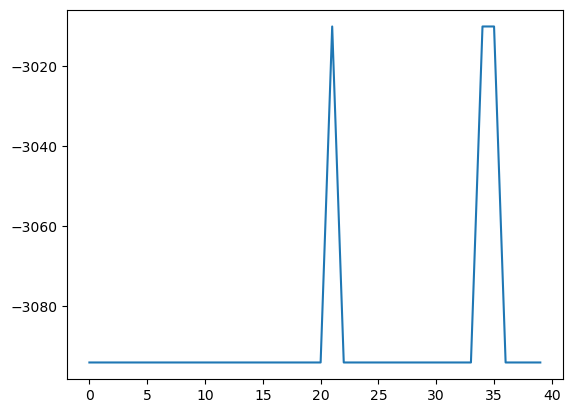

In [63]:
plt.plot(zstar_t[:,36,  270, 300])

In [68]:
rho_sulu.rho.isel(time=35).values[36, 270, 300]

997.5686

In [69]:
zstar_t[30, :, 270, 300]-z_centers

NameError: name 'z_centers' is not defined

In [ ]:
zstar_mean.values[:,36,  270, 300]-z_centers

array([   0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,  -73.65429688, -139.68530273,
       -199.11743164, -192.18457031, -185.49291992,  199.11743164,
        405.52416992, -166.78393555, -552.875     , -666.6953125 ,
       -780.85913086, -621.07714844, -447.14526367,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           

In [135]:
# plot energy flux 

ds_c1 = xr.open_dataset('first_phase_speed_sulu.nc')

c1 = ds_c1.first_phase_speed.values

In [136]:
E_flux = c1*(np.mean(ape_f_bp_int[:, :, :]+ke_bp_int[:, :, :], axis=0))

Text(0.5, 1.0, 'Available Energy Flux (W/m)')

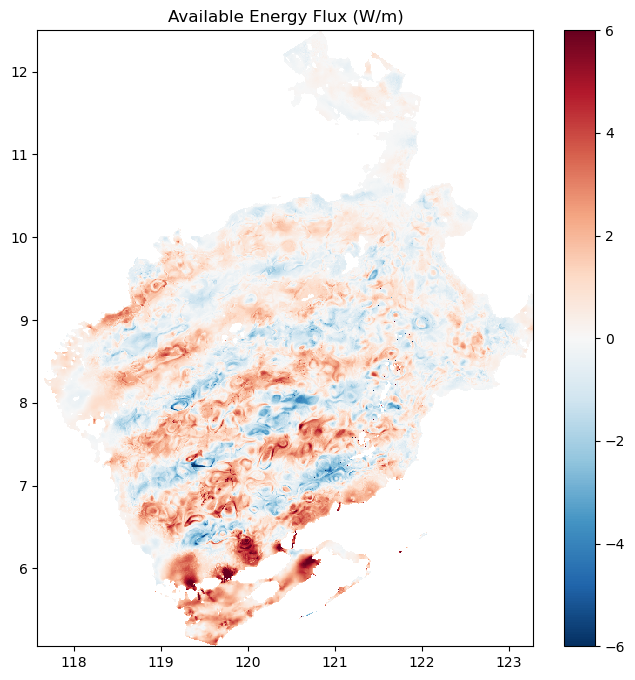

In [192]:
plt.figure(figsize=(8,8))
plt.pcolormesh(lon_sulu, lat_sulu, E_flux, cmap='RdBu_r', vmin=-6, vmax=6)
plt.colorbar()
plt.title('Available Energy Flux (W/m)')

In [150]:
ds_fx_ver_int = xr.open_zarr('zarr_output/fx_ver_int.zarr/', consolidated=False)
ds_fy_ver_int = xr.open_zarr('zarr_output/fy_ver_int.zarr/', consolidated=False)
ds_fx_ver_int_sulu = ds_fx_ver_int.fx_ver_int.isel(y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))
ds_fy_ver_int_sulu = ds_fy_ver_int.fy_ver_int.isel(y=slice(i_min, i_max+1), x=slice(j_min, j_max+1))
rho0 = 998.5
fx_ver_int2 = (ds_fx_ver_int_sulu*np.sum(hFacC_subset*dr[:, None, None], axis=0))*rho0
fy_ver_int2 = (ds_fy_ver_int_sulu*np.sum(hFacC_subset*dr[:, None, None], axis=0))*rho0

# ds_fx_ver_int

In [153]:
fx_ver_int2_time_mean = fx_ver_int2.isel(time=slice(400,450)).mean(dim='time')
fy_ver_int2_time_mean = fy_ver_int2.isel(time=slice(400,450)).mean(dim='time')

fxy_ver_int2_time_mean = np.sqrt(fx_ver_int2_time_mean**2 + fy_ver_int2_time_mean**2)

In [166]:
fx_ver_int2_time_mean_by_ape = fx_ver_int2_time_mean/(np.mean(ape_f_bp_int[:, :, :]+ke_bp_int[:, :, :], axis=0)*c1)
fy_ver_int2_time_mean_by_ape = fy_ver_int2_time_mean/(np.mean(ape_f_bp_int[:, :, :]+ke_bp_int[:, :, :], axis=0)*c1)
fxy_ver_int2_time_mean_by_ape = fxy_ver_int2_time_mean/(np.mean(ape_f_bp_int[:, :, :]+ke_bp_int[:, :, :], axis=0)*c1)

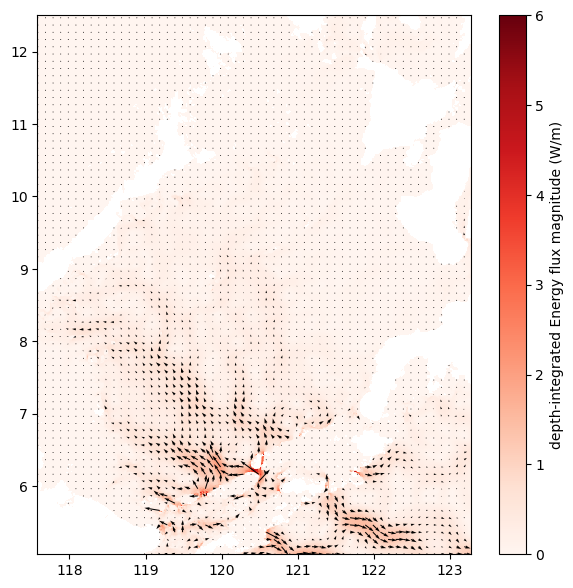

In [157]:
plt.figure(figsize=(7,7))
plt.pcolormesh(lon_sulu,lat_sulu, fxy_ver_int2_time_mean, cmap='Reds', vmin=0, vmax=6)
plt.colorbar(label='depth-integrated Energy flux magnitude (W/m)')
plt.quiver(lon_sulu[0:-1:10], lat_sulu[0:-1:10], 
           fx_ver_int2_time_mean[0:-1:10, 0:-1:10], fy_ver_int2_time_mean[0:-1:10, 0:-1:10], scale=60)


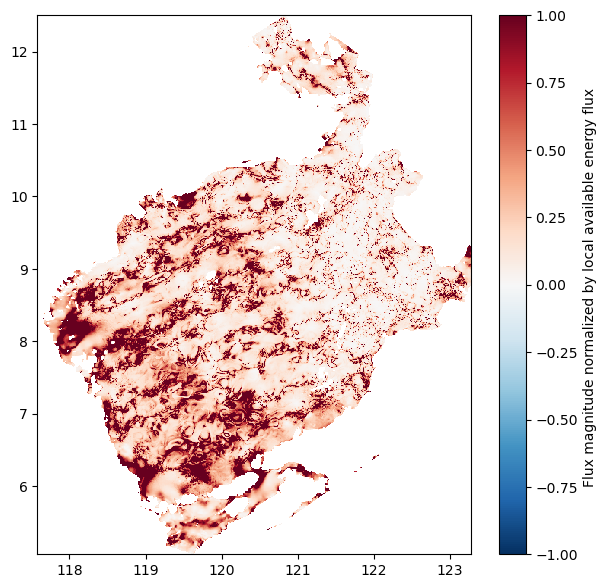

In [193]:
plt.figure(figsize=(7,7))
plt.pcolormesh(lon_sulu,lat_sulu, np.abs(fxy_ver_int2_time_mean_by_ape), cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Flux magnitude normalized by local available energy flux ')
# plt.quiver(lon_sulu[0:-1:10], lat_sulu[0:-1:10], 
#            fx_ver_int2_time_mean_by_ape[0:-1:10, 0:-1:10], fy_ver_int2_time_mean_by_ape[0:-1:10, 0:-1:10], scale=150)
